**A. Membangun struktur direktori HDFS**

In [2]:
!hdfs dfs -mkdir -p /user/asfadani/ecommerce/raw

In [4]:
!hdfs dfs -mkdir -p /user/asfadani/ecommerce/processed

Setelah membuat direktori cek terlebih dahulu untuk memastikan direktori nya sudah ada.

In [7]:
!hdfs dfs -ls /user/asfadani/ecommerce

Found 2 items
drwxr-xr-x   - asfadani supergroup          0 2026-09-05 09:07 /user/asfadani/ecommerce/processed
drwxr-xr-x   - asfadani supergroup          0 2026-09-05 09:06 /user/asfadani/ecommerce/raw


**B. Mengunggah data mentah ke HDFS**

In [8]:
!hdfs dfs -put transaksi_magelang.csv, transaksi_semarang.csv, transaksi_yogyakarta.csv /user/asfadani/ecommerce/raw

put: `transaksi_magelang.csv,': No such file or directory
put: `transaksi_semarang.csv,': No such file or directory


In [10]:
!hdfs dfs -put transaksi_semarang.csv /user/asfadani/ecommerce/raw

In [11]:
!hdfs dfs -put transaksi_magelang.csv /user/asfadani/ecommerce/raw

Melakukan cek keberhasilan unggah file ke HDFS

In [1]:
!hdfs dfs -count /user/asfadani/ecommerce/raw/

!hdfs dfs -ls /user/asfadani/ecommerce/raw


           1            3              37167 /user/asfadani/ecommerce/raw
Found 3 items
-rw-r--r--   1 asfadani supergroup      12329 2026-09-05 09:21 /user/asfadani/ecommerce/raw/transaksi_magelang.csv
-rw-r--r--   1 asfadani supergroup      12154 2026-09-05 09:21 /user/asfadani/ecommerce/raw/transaksi_semarang.csv
-rw-r--r--   1 asfadani supergroup      12684 2026-09-05 09:17 /user/asfadani/ecommerce/raw/transaksi_yogyakarta.csv


**C. Membaca dataset dan menggabungkannya**

In [18]:
!pip install pyarrow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 6.2 MB/s  0:00:08 eta 0:00:010:00:01


In [2]:
import pyarrow.dataset as ds
from pyarrow import fs
import pandas as pd

In [3]:
try:
    hdfs = fs.HadoopFileSystem(host='localhost', port=9000) 
    print("Koneksi HDFS berhasil!")
except Exception as e:
    print(f"Koneksi gagal: {e}")

2026-09-05 10:43:01,888 WARN util.NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Koneksi HDFS berhasil!


In [6]:
# Membaca folder file datasetnya
daftar_file = [
    '/user/asfadani/ecommerce/raw/transaksi_magelang.csv',
    '/user/asfadani/ecommerce/raw/transaksi_semarang.csv',
    '/user/asfadani/ecommerce/raw/transaksi_yogyakarta.csv'
]

# Membuat dataset dari file yang ada di folder
dataset = ds.dataset(daftar_file, filesystem=hdfs, format="csv")

In [8]:
df = dataset.to_table().to_pandas()
display(df.head())
display(df.tail())

,order_id,tanggal,kategori,unit_terjual,harga_satuan,metode_pembayaran,kota
0,MAG-2000,2026-08-12,Fashion,1,50000,Transfer Bank,Magelang
1,MAG-2001,2026-08-18,Elektronik,7,25000,COD,Magelang
2,MAG-2002,2026-08-07,Elektronik,7,25000,E-Wallet,Magelang
3,MAG-2003,2026-08-24,Rumah Tangga,6,25000,COD,Magelang
4,MAG-2004,2026-08-30,Fashion,7,100000,Transfer Bank,Magelang


,order_id,tanggal,kategori,unit_terjual,harga_satuan,metode_pembayaran,kota
595,YOG-2195,2026-08-25,Rumah Tangga,4,250000,Kartu Kredit,Yogyakarta
596,YOG-2196,2026-08-18,Fashion,1,150000,COD,Yogyakarta
597,YOG-2197,2026-08-27,Makanan & Minuman,4,25000,Kartu Kredit,Yogyakarta
598,YOG-2198,2026-08-07,Rumah Tangga,1,25000,COD,Yogyakarta
599,YOG-2199,2026-08-06,Rumah Tangga,1,75000,E-Wallet,Yogyakarta


In [10]:
print(df['kota'].value_counts())

kota
Magelang      200
Semarang      200
Yogyakarta    200
Name: count, dtype: int64


**D. Mengolah data dan Download ke DIrektori**

In [11]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   order_id           600 non-null    str   
 1   tanggal            600 non-null    object
 2   kategori           600 non-null    str   
 3   unit_terjual       600 non-null    int64 
 4   harga_satuan       600 non-null    int64 
 5   metode_pembayaran  600 non-null    str   
 6   kota               600 non-null    str   
dtypes: int64(2), object(1), str(4)
memory usage: 55.2+ KB
None


1. Menambahkan kolom total pendapatan

In [27]:
df['total_pendapatan'] = df['unit_terjual'] * df['harga_satuan']
display(df.head())

,order_id,tanggal,kategori,unit_terjual,harga_satuan,metode_pembayaran,kota,total_pendapatan
0,MAG-2000,2026-08-12,Fashion,1,50000,Transfer Bank,Magelang,50000
1,MAG-2001,2026-08-18,Elektronik,7,25000,COD,Magelang,175000
2,MAG-2002,2026-08-07,Elektronik,7,25000,E-Wallet,Magelang,175000
3,MAG-2003,2026-08-24,Rumah Tangga,6,25000,COD,Magelang,150000
4,MAG-2004,2026-08-30,Fashion,7,100000,Transfer Bank,Magelang,700000


2. Membuat tabel rangkuman

In [40]:
df_rangkuman = df[['kota', 'kategori', 'total_pendapatan']]

In [41]:
display(df_rangkuman.head())
print(df_rangkuman.info())

,kota,kategori,total_pendapatan
0,Magelang,Fashion,50000
1,Magelang,Elektronik,175000
2,Magelang,Elektronik,175000
3,Magelang,Rumah Tangga,150000
4,Magelang,Fashion,700000


<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   kota              600 non-null    str  
 1   kategori          600 non-null    str  
 2   total_pendapatan  600 non-null    int64
dtypes: int64(1), str(2)
memory usage: 26.6 KB
None


In [42]:
df_rangkuman = df_rangkuman.groupby(['kota', 'kategori'], as_index=False).sum()

In [45]:
display(df_rangkuman)

,kota,kategori,total_pendapatan
0,Magelang,Elektronik,18775000
1,Magelang,Fashion,27750000
2,Magelang,Kesehatan & Kecantikan,17375000
3,Magelang,Makanan & Minuman,17525000
4,Magelang,Rumah Tangga,12200000
5,Semarang,Elektronik,21425000
6,Semarang,Fashion,26425000
7,Semarang,Kesehatan & Kecantikan,13525000
8,Semarang,Makanan & Minuman,19750000
9,Semarang,Rumah Tangga,10975000


3. Menyimpan dan mengunggah ke HDFS

In [46]:
df.to_csv('data_gabungan_bersih.csv', index=False)
df_rangkuman.to_csv('ringkasan_kota_kategori.csv', index=False)
print("Berhasil menyimpan file csv")

Berhasil menyimpan file csv


In [47]:
!hdfs dfs -put data_gabungan_bersih.csv /user/asfadani/ecommerce/processed
!hdfs dfs -put ringkasan_kota_kategori.csv /user/asfadani/ecommerce/processed

In [48]:
!hdfs dfs -ls /user/asfadani/ecommerce/processed

Found 2 items
-rw-r--r--   1 asfadani supergroup      41257 2026-09-05 11:32 /user/asfadani/ecommerce/processed/data_gabungan_bersih.csv
-rw-r--r--   1 asfadani supergroup        530 2026-09-05 11:32 /user/asfadani/ecommerce/processed/ringkasan_kota_kategori.csv


**E. Dokumentasi dan Refleksi**

1. Screenshoot halaman HDFS

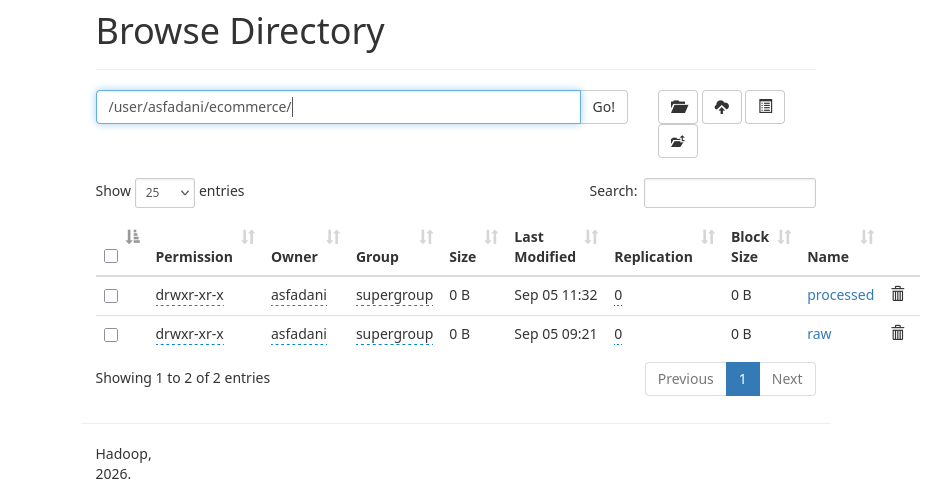

2. Salah satu keuntungan yang paling jelas dari menyimpan file dataset yang telah dilakukan pemrosesan (dibersihkan, dan sebagainya) dengan yang mentah di 2 folder berbeda adalah kerapian dan kemudahan untuk mengaksesnya. Jika file jadi dengan file mentah disatukan kita akan bingung jika suatu saat ingin membutuhkan filenya untuk sebuah projek. Selain itu juga menyimpan file dengan kondisi berbeda juga menjadi salah satu syarat clean architecture di dunia pemrograman. Pembagian penyimpanan data ini juga memudahkan dalam pengerjaan kolaborasi, sehingga orang lain yang akan mengakses datanya tidak kebingungan. Dalam pelacakan perubahan dari datanya juga menjadi mudah jika datanya disimpan ke folder yang berbeda. Selain itu juga membuat proses lebih efisien pada pipeline project, untuk mengatur data diambil dari mana dan akan disimpan di mana nantinya.